# Graphe Hydrographique

## Import des librairies

In [45]:
import pathlib
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import pyproj
import networkx as nx
from shapely import Point, LineString, MultiLineString, GeometryCollection, STRtree
from shapely.ops import split, snap, linemerge, unary_union
from tqdm.auto import tqdm
from shapely import box
import shapely
import pickle
from collections import deque
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import requests

# I. Premiers essais de tracés

### 1. Prétraitement des données

On commence par travailler avec trois bases de données : les cours d'eau, les tronçons hydrographiques, et les sites (qui correspondent aux stations de relevé de températures).

In [46]:
# Code OH de la Seine
Code_OH = "03C00000020008"

# Geofframe des cours d'eau et prétraitement pour ne récupérer que la Seine
gdf_ce = gpd.read_file("données hackaton/CoursEau/CoursEau_FXX.shp")

m = gdf_ce['CdOH'].str.startswith(Code_OH)
seine_ce = gdf_ce[m].copy()


# Geoframe des tronçons hydrographiques et prétraitement
bbox = box(490000, 6658000, 861000, 6981000)
gdf_tr = gpd.read_file(
    "données hackaton/TronconHydrographique/TronconHydrographique_FXX.shp",
    bbox=bbox,
).set_index("CdOH")

patch = {
    "03T0000002287758528": {"TopoOH": "la Marne", "CdCoursEau": "03C0000002000815787"},
    "03T0000002287758537": {"TopoOH": "la Marne", "CdCoursEau": "03C0000002000815787"},
}

gdf_tr.update(pd.DataFrame.from_dict(patch, orient="index"))

m = gdf_tr['CdCoursEau'].fillna("").str.startswith(Code_OH)
seinetr = gdf_tr[m].copy()
seinetr["geometry"] = seinetr.force_2d()

# Geoframe des stations
sites = gpd.read_file("données hackaton/Sites/Sites.shp")

In [47]:
# Chargement des stations hydrométriques Hubeau pour "La Seine"

url_stations = "https://hubeau.eaufrance.fr/api/v2/hydrometrie/referentiel/stations"
params_stations = {"format": "geojson", "size": 10000}

gj = requests.get(url_stations, params=params_stations, timeout=60).json()
gdf_hubeau = gpd.GeoDataFrame.from_features(gj["features"], crs="EPSG:4326")

# Filtre sur le libellé du cours d'eau : uniquement "La Seine"
cours_eau_retenus = ["La Seine", "L'Yonne", "La Marne", "L'Oise"]
gdf_hubeau = gdf_hubeau[gdf_hubeau["libelle_cours_eau"].isin(cours_eau_retenus)].copy()

# Reprojection en Lambert-93, clip à la bbox, dédoublonnage
gdf_hubeau = gdf_hubeau.to_crs("EPSG:2154")
gdf_hubeau = gdf_hubeau.clip(bbox)
gdf_hubeau = gdf_hubeau.drop_duplicates(subset="code_station")
gdf_hubeau = gdf_hubeau.rename(columns={"libelle_station": "Libellé"})
gdf_hubeau["source"] = "hubeau"

sites_hubeau = gdf_hubeau[["Libellé", "geometry", "source"]].reset_index(drop=True).copy()
print(f"{len(sites_hubeau)} stations Hubeau retenues sur la Seine, l'Yonne, la Marne et l'Oise")

189 stations Hubeau retenues sur la Seine, l'Yonne, la Marne et l'Oise


In [48]:
def snap_key(coord, ndigits=6):
    """
    Arrondit une coordonnée (x, y) à `ndigits` décimales, pour l'utiliser
    comme clé de nœud stable dans le graphe. En Lambert-93 (EPSG:2154),
    les coordonnées sont exprimées en mètres : 6 décimales correspond donc
    à une précision de l'ordre du micromètre, largement suffisante pour
    absorber les micro-dérives flottantes introduites par des opérations
    géométriques successives (snap/split/linemerge) sans jamais confondre
    deux vertices réellement distincts.
    """
    return (round(coord[0], ndigits), round(coord[1], ndigits))

In [49]:
# Station à l'estuaire
root_node = sites.loc[sites["Libellé"] == "Balise fond", "geometry"]
root_node = snap_key(root_node.squeeze().coords[0])

### 2. Graphe construit avec les cours d'eau uniquement

In [82]:
sites_ce1 = sites[~sites.is_empty].reset_index(drop=True).copy()
sites_ce1["source"] = "sites_existants"

station_hydro = sites_hubeau[~sites_hubeau.is_empty].reset_index(drop=True).copy()
# station_hydro possède déjà une colonne "source" = "hubeau"

seine_ce1 = seine_ce.explode(ignore_index=True)
geom_col_s1 = seine_ce1.columns.get_loc("geometry")

# Fusion sites + stations dans une seule collection, avec traçabilité
# de l'origine ("kind") et de l'index d'origine (pour retrouver site_id ensuite)
points = pd.concat(
    [
        sites_ce1[["Libellé", "geometry", "source"]]
            .assign(orig_index=sites_ce1.index, kind="sites_existants"),
        station_hydro[["Libellé", "geometry", "source"]]
            .assign(orig_index=station_hydro.index, kind="hubeau"),
    ],
    ignore_index=True,
)

points = gpd.GeoDataFrame(points, geometry="geometry", crs=seine_ce1.crs)
geom_col_p = points.columns.get_loc("geometry")

# Recherche du tronçon le plus proche pour CHAQUE point (une seule fois,
# sur l'état initial de seine_ce1)
pos1, pos2 = seine_ce1.sindex.nearest(points["geometry"], return_all=False)

topo_touched = []  # TopoOH des tronçons ayant reçu au moins un point

for i1, i2 in zip(pos1, pos2):
    pt = points.iloc[i1, geom_col_p]
    ls = seine_ce1.iloc[i2, geom_col_s1]

    proj_pt = ls.interpolate(ls.project(pt))   # projection du point sur la ligne
    snap_ls = snap(ls, proj_pt, 1e-6)          # on "accroche" la ligne au point projeté
    split_ls = split(snap_ls, proj_pt)         # on découpe la ligne au point projeté
    split_ls = linemerge(split_ls)

    # Récupération de la coordonnée EXACTE insérée dans split_ls
    # (appliqué systématiquement à TOUS les points, sites ET stations)
    if hasattr(split_ls, "geoms"):
        coords_array = np.array([c for geom in split_ls.geoms for c in geom.coords])
    else:
        coords_array = np.array(split_ls.coords)
    dists = np.linalg.norm(coords_array - np.array(proj_pt.coords[0]), axis=1)
    exact_coord = Point(coords_array[np.argmin(dists)])

    points.iloc[i1, geom_col_p] = exact_coord
    seine_ce1.iloc[i2, geom_col_s1] = split_ls

    topo_touched.append(seine_ce1.iloc[i2]["TopoOH"])

# On ne garde que les tronçons appartenant aux mêmes cours d'eau (TopoOH)
# que ceux ayant reçu au moins un point (site existant ou station Hubeau)
topo = pd.Series(topo_touched).dropna().drop_duplicates().to_list()
seine3 = seine_ce1[seine_ce1["TopoOH"].isin(topo)]

# Correction finale de précision : plusieurs points peuvent tomber sur un
# même tronçon d'origine. Lorsqu'un tronçon est splitté/linemerge plusieurs
# fois de suite (un point après l'autre), le vertex du premier point inséré
# peut subir une micro-dérive flottante lors du traitement du point suivant.
# Plutôt que de rechercher le vertex le plus proche, on normalise toutes les
# coordonnées utilisées comme clés de nœud via snap_key() : cette dérive est
# de l'ordre de 1e-9 à 1e-12, largement absorbée par l'arrondi à 6 décimales.

# On resépare sites_ce1 / station_hydro à partir de "points"
sites_ce1 = (
    points[points["kind"] == "sites_existants"]
    .set_index("orig_index")[["Libellé", "geometry", "source"]]
)
station_hydro = (
    points[points["kind"] == "hubeau"]
    .set_index("orig_index")[["Libellé", "geometry", "source"]]
)

In [83]:
G = nx.Graph()

# chaque point de la LineString devient un nœud du graphe,
# chaque segment devient une arête avec un poids égal à sa longueur

for _, row in tqdm(seine3.iterrows(), total=len(seine3)):
    geom = row.geometry
    for i, j in zip(geom.coords, geom.coords[1:]):
        i, j = snap_key(i), snap_key(j)
        G.add_edge(i, j, weight=LineString([i, j]).length)


site_nodes = []

# Ajout des sites existants comme nœuds du graphe
for site in sites_ce1.itertuples():
    coord = snap_key(site.geometry.coords[0])
    attrs = G.nodes[coord]
    attrs["site_id"] = site.Index
    attrs["label"] = site.Libellé
    attrs["source"] = "sites_existants"
    site_nodes.append(coord)

# Ajout des stations Hubeau comme nœuds du graphe
# (snap_key absorbe les micro-dérives flottantes issues des splits successifs)
for station in station_hydro.itertuples():
    coord = snap_key(station.geometry.coords[0])
    attrs = G.nodes[coord]
    attrs["site_id"] = station.Index
    attrs["label"] = station.Libellé
    attrs["source"] = "hubeau"
    site_nodes.append(coord)

  0%|          | 0/1091 [00:00<?, ?it/s]

In [84]:
lengths_dij, paths = nx.single_source_dijkstra(G, root_node, weight="weight")

colors = []
for site in tqdm(site_nodes):
    attrs = G.nodes[site]
    if site in paths:
        if attrs.get("source") == "hubeau":
            colors.append("blue")
        else:
            colors.append("green")
    else:
        print(f"Aucun chemin trouvé vers {attrs['label']}")
        colors.append("red")

  0%|          | 0/271 [00:00<?, ?it/s]

Aucun chemin trouvé vers Joinville-le-Pont
Aucun chemin trouvé vers Neuilly-sur-Marne
Aucun chemin trouvé vers Parc St Maur
Aucun chemin trouvé vers Créteil
Aucun chemin trouvé vers Reuil
Aucun chemin trouvé vers Charenton (Bry)
Aucun chemin trouvé vers La Ferté-sous-Jouarre
Aucun chemin trouvé vers Matougues
Aucun chemin trouvé vers Frignicourt
Aucun chemin trouvé vers Riaucourt
Aucun chemin trouvé vers Annet-sur-Marne
Aucun chemin trouvé vers La Marne à Chaumont [Reclancourt]
Aucun chemin trouvé vers La Marne à Condes
Aucun chemin trouvé vers La Marne à Mussey-sur-Marne
Aucun chemin trouvé vers La Marne à Joinville
Aucun chemin trouvé vers La Marne à Azy-sur-Marne - Barrage (aval) [VNF]
Aucun chemin trouvé vers La Marne à Chamouilley
Aucun chemin trouvé vers La Marne à Saint-Dizier - Hôpital
Aucun chemin trouvé vers La Marne à Saint-Dizier - Après création des grands lacs
Aucun chemin trouvé vers La Marne à Saint-Dizier - Après création des grands lacs
Aucun chemin trouvé vers La Mar

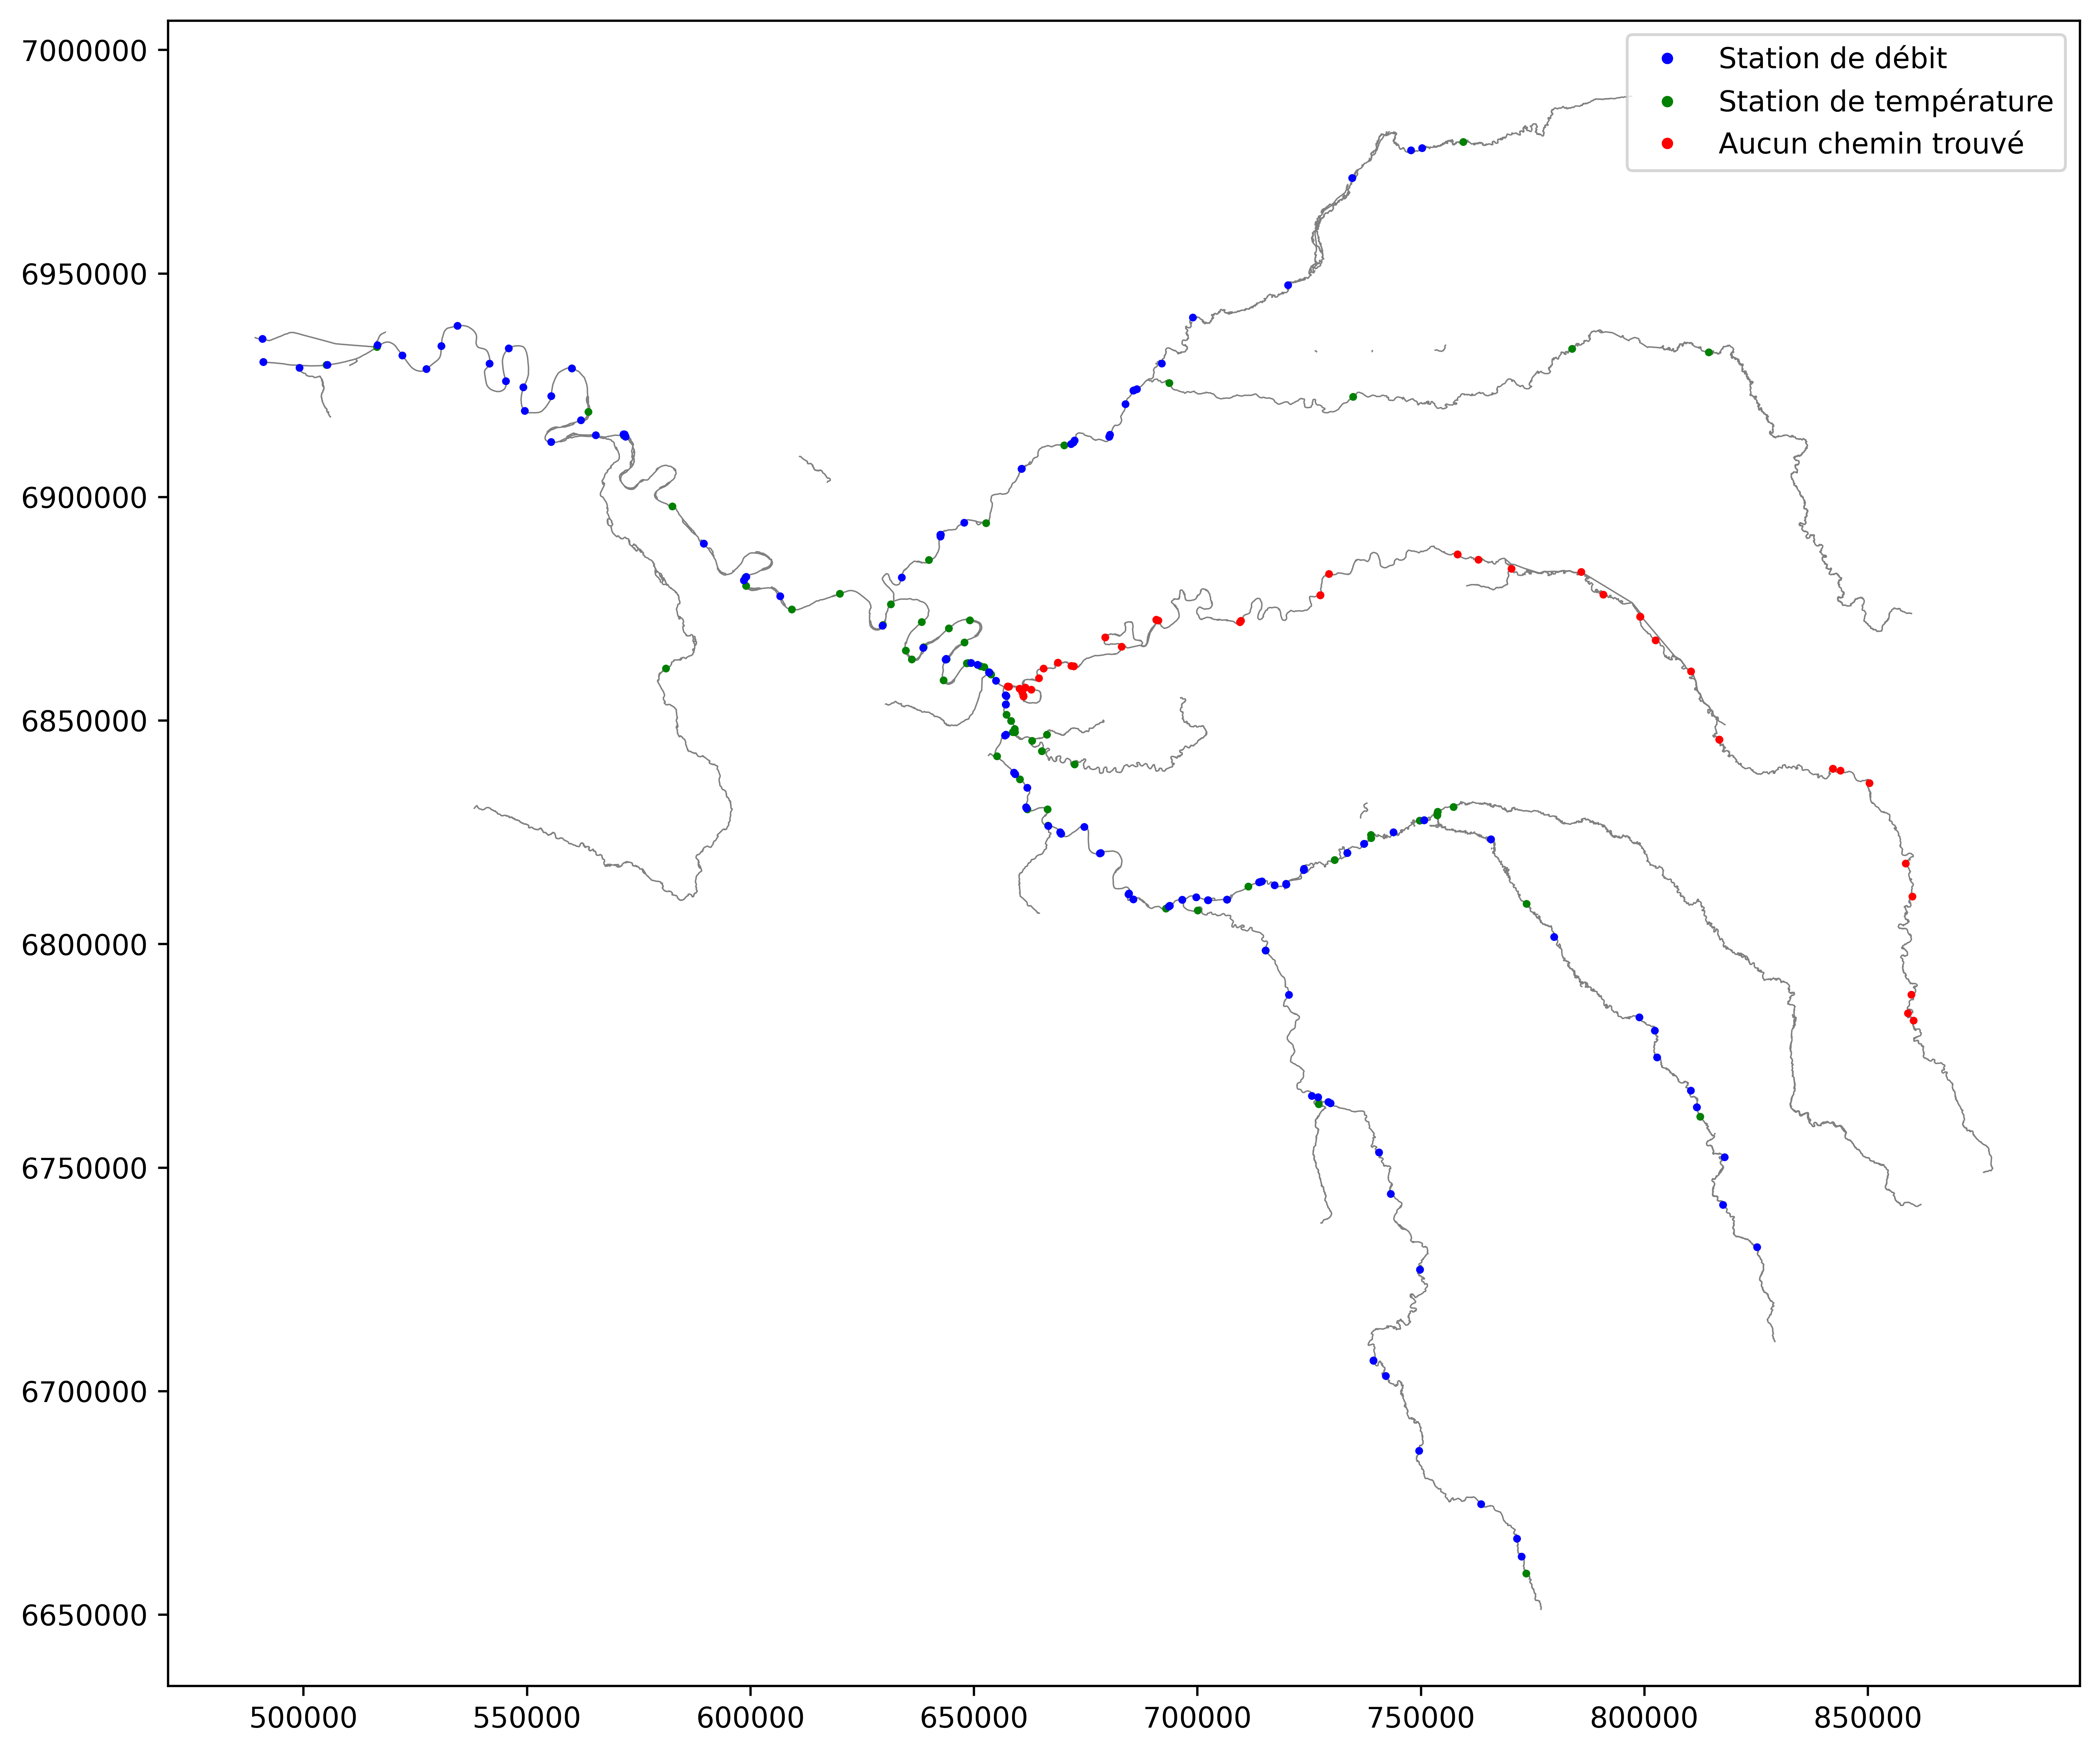

In [85]:
fig, ax = plt.subplots(figsize = (12,12), dpi = 600)
seine3.plot(ax = ax, lw = 0.5, color = "grey", zorder = -1)
points.plot(ax = ax, lw = 0.5, color = colors, markersize = 5)
ax.ticklabel_format(style = 'plain', axis = 'both')
plt.legend(handles=[
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='blue', markersize=5, label='Station de débit'),
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='green', markersize=5, label='Station de température'),
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='red', markersize=5, label='Aucun chemin trouvé')
])
plt.show()

### 3. Graphe construit avec les tronçons hydrographiques uniquement

In [86]:
sites_tr1 = sites[~sites.is_empty].reset_index(drop=True).copy()
sites_tr1["source"] = "sites_existants"

station_hydro = sites_hubeau[~sites_hubeau.is_empty].reset_index(drop=True).copy()
# station_hydro possède déjà une colonne "source" = "hubeau"

seine_tr1 = seinetr.explode(ignore_index=True)
geom_col_t1 = seine_tr1.columns.get_loc("geometry")

# Fusion sites + stations dans une seule collection, avec traçabilité
# de l'origine ("kind") et de l'index d'origine (pour retrouver site_id ensuite)
points = pd.concat(
    [
        sites_tr1[["Libellé", "geometry", "source"]]
            .assign(orig_index=sites_tr1.index, kind="sites_existants"),
        station_hydro[["Libellé", "geometry", "source"]]
            .assign(orig_index=station_hydro.index, kind="hubeau"),
    ],
    ignore_index=True,
)

points = gpd.GeoDataFrame(points, geometry="geometry", crs=seine_tr1.crs)
geom_col_p = points.columns.get_loc("geometry")

# Recherche du tronçon le plus proche pour CHAQUE point (une seule fois,
# sur l'état initial de seine_tr1)
pos1, pos2 = seine_tr1.sindex.nearest(points["geometry"], return_all=False)

topo_touched = []  # TopoOH des tronçons ayant reçu au moins un point

for i1, i2 in zip(pos1, pos2):
    pt = points.iloc[i1, geom_col_p]
    ls = seine_tr1.iloc[i2, geom_col_t1]

    proj_pt = ls.interpolate(ls.project(pt))   # projection du point sur la ligne
    snap_ls = snap(ls, proj_pt, 1e-6)          # on "accroche" la ligne au point projeté
    split_ls = split(snap_ls, proj_pt)         # on découpe la ligne au point projeté
    split_ls = linemerge(split_ls)

    if hasattr(split_ls, "geoms"):
        coords_array = np.array([c for geom in split_ls.geoms for c in geom.coords])
    else:
        coords_array = np.array(split_ls.coords)
    dists = np.linalg.norm(coords_array - np.array(proj_pt.coords[0]), axis=1)
    exact_coord = Point(coords_array[np.argmin(dists)])

    points.iloc[i1, geom_col_p] = exact_coord
    seine_tr1.iloc[i2, geom_col_t1] = split_ls

    topo_touched.append(seine_tr1.iloc[i2]["TopoOH"])


topo = pd.Series(topo_touched).dropna().drop_duplicates().to_list()
seine2 = seine_tr1[seine_tr1["TopoOH"].isin(topo)]

sites_tr1 = (
    points[points["kind"] == "sites_existants"]
    .set_index("orig_index")[["Libellé", "geometry", "source"]]
)
station_hydro = (
    points[points["kind"] == "hubeau"]
    .set_index("orig_index")[["Libellé", "geometry", "source"]]
)

In [87]:
G1 = nx.Graph()

for _, row in tqdm(seine2.iterrows(), total=len(seine2)):
    geom = row.geometry
    parts = list(geom.geoms) if geom.geom_type == 'MultiLineString' else [geom]
    for part in parts:
        for i, j in zip(part.coords, part.coords[1:]):
            i, j = snap_key(i), snap_key(j)
            G1.add_edge(i, j, weight=LineString([i, j]).length)  # G1 et non G

site_nodes = []

for site in sites_tr1.itertuples():
    coord = snap_key(site.geometry.coords[0])
    if coord not in G1.nodes:
        print(f"Nœud introuvable pour '{site.Libellé}'")
        continue
    G1.nodes[coord]["site_id"] = site.Index
    G1.nodes[coord]["label"] = site.Libellé
    G1.nodes[coord]["source"] = "sites_existants"
    site_nodes.append(coord)

for station in station_hydro.itertuples():
    coord = snap_key(station.geometry.coords[0])
    if coord not in G1.nodes:
        print(f"Nœud introuvable pour '{station.Libellé}'")
        continue
    G1.nodes[coord]["site_id"] = station.Index
    G1.nodes[coord]["label"] = station.Libellé
    G1.nodes[coord]["source"] = "hubeau"
    site_nodes.append(coord)

  0%|          | 0/8189 [00:00<?, ?it/s]

In [88]:
lengths_dij, paths = nx.single_source_dijkstra(G1, root_node, weight="weight")

colors1 = []
for site in tqdm(site_nodes):
    attrs = G1.nodes[site]
    if site in paths:
        if attrs.get("source") == "hubeau":
            colors1.append("blue")
        else:
            colors1.append("green")
    else:
        print(f"Aucun chemin trouvé vers {attrs['label']}")
        colors1.append("red")

  0%|          | 0/271 [00:00<?, ?it/s]

Aucun chemin trouvé vers Erloy
Aucun chemin trouvé vers Château-Chinon
Aucun chemin trouvé vers Prégilbert
Aucun chemin trouvé vers L'Yonne à Château-Chinon (Campagne)
Aucun chemin trouvé vers L'Yonne à Corancy
Aucun chemin trouvé vers L'Yonne à Montigny-en-Morvan [Chassy]
Aucun chemin trouvé vers L'Yonne à Marigny-sur-Yonne
Aucun chemin trouvé vers L'Yonne à Dornecy
Aucun chemin trouvé vers L'Yonne à Clamecy
Aucun chemin trouvé vers L'Yonne à Clamecy - Débit
Aucun chemin trouvé vers L'Yonne à Prégilbert
Aucun chemin trouvé vers L'Oise à Flavigny-le-Grand-et-Beaurain
Aucun chemin trouvé vers L'Oise à Monceau-sur-Oise


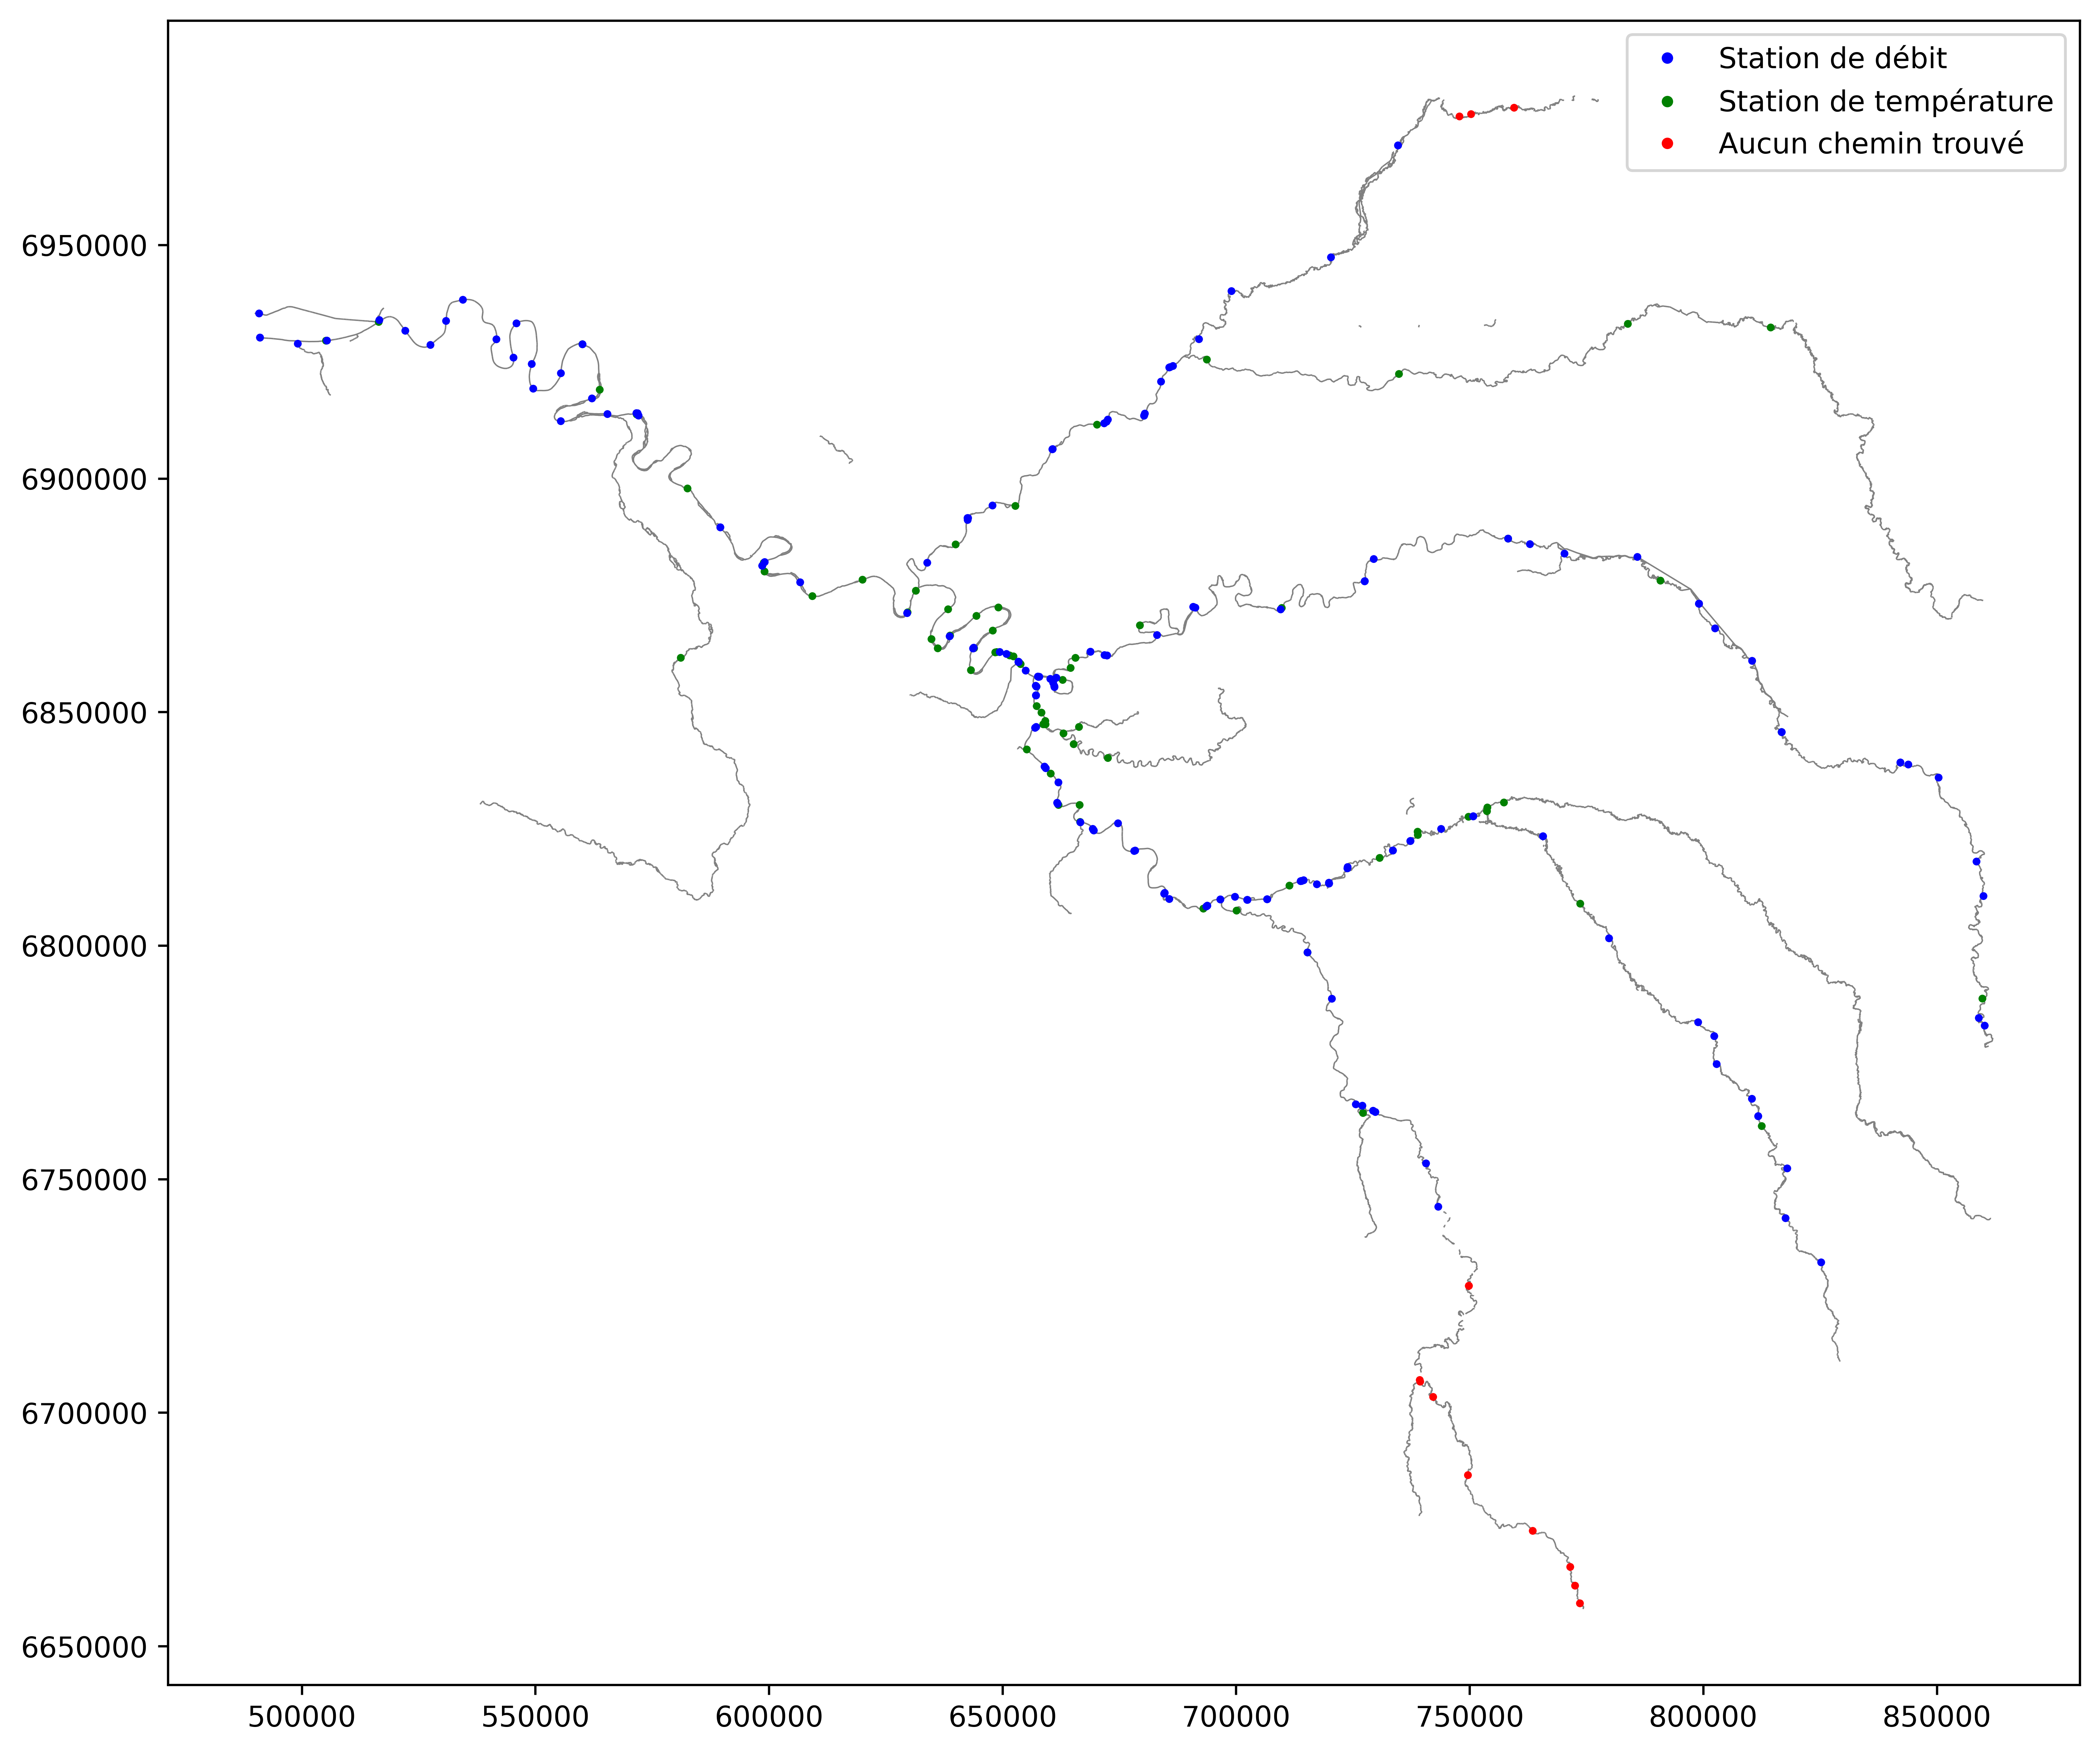

In [89]:
fig, ax = plt.subplots(figsize = (12,12), dpi = 600)
seine2.plot(ax = ax, lw = 0.5, color = "grey", zorder = -1)
points.plot(ax = ax, lw = 0.5,color = colors1, markersize = 5)
ax.ticklabel_format(style = 'plain', axis = 'both')
plt.legend(handles=[
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='blue', markersize=5, label='Station de débit'),
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='green', markersize=5, label='Station de température'),
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='red', markersize=5, label='Aucun chemin trouvé')
])
plt.show()

# II. Contraction du graphe

On implémente une fonction de contraction du graphe pour diminuer sa taille et donc réduire le volume occupé/le temps de traitement, tout en gardant en mémoire les distances réelles associées aux différents cours d'eau.

In [60]:
def contract(g):
    """
    Contract chains of neighbouring vertices with degree 2 into a single edge.

    Arguments:
    ----------
    g -- networkx.Graph or networkx.DiGraph instance

    Returns:
    --------
    h -- networkx.Graph or networkx.DiGraph instance
        the contracted graph
    """

    # Travailler sur la version non orientée pour identifier les chaînes
    ug = g.to_undirected() if g.is_directed() else g

    # Créer le sous-graphe des nœuds de degré 2
    is_chain = [node for node, degree in ug.degree() if ((degree == 2) and (g.nodes[node].get("site_id") is None))]
    chains = ug.subgraph(is_chain)

    # Correction : connected_component_subgraphs supprimé en NX 2.4+
    # On applique connected_components sur chains (pas sur g)
    components = [chains.subgraph(c) for c in nx.connected_components(chains)]

    hyper_edges = []
    for component in components:
        end_points = [node for node, degree in component.degree() if degree < 2]
        candidates = set(neighbor for node in end_points for neighbor in ug.neighbors(node))
        connectors = list(candidates - set(component.nodes()))
        weights = [data.get('weight', 1) for _, _, data in component.edges(data=True)]
        hyper_edges.append((connectors, np.sum(weights)))

    # Initialiser le nouveau graphe sans les nœuds de degré 2
    not_chain = [node for node in g.nodes() if node not in is_chain]
    h = g.subgraph(not_chain).copy()
    for connectors, weight in hyper_edges:
        # Garde-fou : une chaîne en bout de graphe peut avoir < 2 connecteurs
        if len(connectors) == 2:
            h.add_edge(connectors[0], connectors[1], weight=weight)

    return h

# III. Concaténation des db Cours d'eau et tronçons hydrographiques (graphe hydrographique connexe)

But de la section : on voit sur les deux exemples faits précédemment avec la Seine que les stations qui ne sont "pas reliées" à l'estuaire sont différentes selon les df utilisés de base. On va donc considérer que merge les deux dataframes permet de combler les gap.

In [61]:
cours_eau_seine = seine_ce.to_crs(2154)
tronçons_seine = seinetr.to_crs(2154)

In [62]:
noded_geometry = unary_union(list(cours_eau_seine.geometry) + list(tronçons_seine.geometry))

if hasattr(noded_geometry, "geoms"):
    lines_list = list(noded_geometry.geoms)
else:
    lines_list = [noded_geometry]

noded_gdf = gpd.GeoDataFrame(geometry=lines_list, crs=2154)

In [63]:
noded_gdf['midpoint'] = noded_gdf.geometry.interpolate(0.5, normalized=True)
noded_gdf_pts = noded_gdf.set_geometry('midpoint')

combined_attributes = pd.concat([cours_eau_seine, tronçons_seine], ignore_index=True)

joined = gpd.sjoin_nearest(noded_gdf_pts, combined_attributes, how='left', max_distance=1.0)
joined = joined[~joined.index.duplicated(keep='first')]  # évite les doublons de jointure à distance égale

if 'geometry_left' in joined.columns:
    combined1 = joined.set_geometry('geometry_left').drop(columns=['midpoint', 'geometry_right'])
else:
    combined1 = joined.set_geometry('geometry').drop(columns=['midpoint'])

combined1 = combined1.reset_index(drop=True)
combined1_exp = combined1.explode(ignore_index=True)

La cellule du dessus compile en 14 minutes et quelques, faut juste être TRES patient.e, et par pitié ne pas la relancer.

In [65]:
sites_tr1 = sites[~sites.is_empty].reset_index(drop=True).copy()
sites_tr1["source"] = "sites_existants"

station_hydro = sites_hubeau[~sites_hubeau.is_empty].reset_index(drop=True).copy()
# station_hydro possède déjà une colonne "source" = "hubeau"

points = pd.concat(
    [
        sites_tr1[["Libellé", "geometry", "source"]]
            .assign(orig_index=sites_tr1.index, kind="sites_existants"),
        station_hydro[["Libellé", "geometry", "source"]]
            .assign(orig_index=station_hydro.index, kind="hubeau"),
    ],
    ignore_index=True,
)
points = gpd.GeoDataFrame(points, geometry="geometry", crs=combined1_exp.crs)

geom_col = combined1_exp.columns.get_loc("geometry")
geom_col_p = points.columns.get_loc("geometry")

pos1, pos2 = combined1_exp.sindex.nearest(points["geometry"], return_all=False)

topo_touched = []

for i1, i2 in zip(pos1, pos2):
    pt = points.iloc[i1, geom_col_p]
    ls = combined1_exp.iloc[i2, geom_col]

    proj_pt = ls.interpolate(ls.project(pt))
    snap_ls = snap(ls, proj_pt, 1e-6)
    split_ls = split(snap_ls, proj_pt)
    split_ls = linemerge(split_ls)

    if hasattr(split_ls, "geoms"):
        coords_array = np.array([c for geom in split_ls.geoms for c in geom.coords])
    else:
        coords_array = np.array(list(split_ls.coords))
    dists = np.linalg.norm(coords_array - np.array(proj_pt.coords[0]), axis=1)
    exact_coord = Point(coords_array[np.argmin(dists)])

    points.iloc[i1, geom_col_p] = exact_coord
    combined1_exp.iloc[i2, geom_col] = split_ls

    topo_touched.append(combined1_exp.iloc[i2]["TopoOH"])


topo = pd.Series(topo_touched).dropna().drop_duplicates().to_list()
seine0 = combined1_exp[combined1_exp["TopoOH"].isin(topo)]
seine0.to_file("Graphs/reseau_seine.gpkg", driver="GPKG") # sauvegarde

sites1 = (
    points[points["kind"] == "sites_existants"]
    .set_index("orig_index")[["Libellé", "geometry", "source"]]
)
station_hydro = (
    points[points["kind"] == "hubeau"]
    .set_index("orig_index")[["Libellé", "geometry", "source"]]
)

In [67]:
G2 = nx.Graph()
edges = []

for geom in tqdm(seine0.geometry.values, total=len(seine0)):
    parts = list(geom.geoms) if geom.geom_type == 'MultiLineString' else [geom]
    for part in parts:
        coords = np.asarray(part.coords)
        if len(coords) < 2:
            continue
        diffs = coords[1:] - coords[:-1]
        lengths = np.hypot(diffs[:, 0], diffs[:, 1])
        for (x1, y1), (x2, y2), length in zip(coords[:-1], coords[1:], lengths):
            edges.append((snap_key((x1, y1)), snap_key((x2, y2)), length))

G2.add_weighted_edges_from(edges)


site_nodes = []

for idx, site in sites1.iterrows():
    coord = snap_key(site["geometry"].coords[0])
    if coord not in G.nodes:
        print(f"Nœud introuvable pour '{site['Libellé']}'")
        continue
    G2.nodes[coord]["site_id"] = idx
    G2.nodes[coord]["label"] = site["Libellé"]
    G2.nodes[coord]["source"] = "sites_existants"
    site_nodes.append(coord)

for idx, station in station_hydro.iterrows():
    coord = snap_key(station["geometry"].coords[0])
    if coord not in G2.nodes:
        print(f"Nœud introuvable pour '{station['Libellé']}'")
        continue
    G2.nodes[coord]["site_id"] = idx
    G2.nodes[coord]["label"] = station["Libellé"]
    G2.nodes[coord]["source"] = "hubeau"
    site_nodes.append(coord)

  0%|          | 0/145430 [00:00<?, ?it/s]

ERROR! Session/line number was not unique in database. History logging moved to new session 274


In [68]:
lengths_dij, paths = nx.single_source_dijkstra(G2, root_node, weight="weight")

colors0 = []
for site in tqdm(site_nodes):
    attrs = G2.nodes[site]
    if site in paths:
        if attrs.get("source") == "hubeau":
            colors0.append("blue")
        else:
            colors0.append("green")
    else:
        print(f"Aucun chemin trouvé vers {attrs['label']}")
        colors0.append("red")

  0%|          | 0/271 [00:00<?, ?it/s]

**Affichage de la version non contractée**

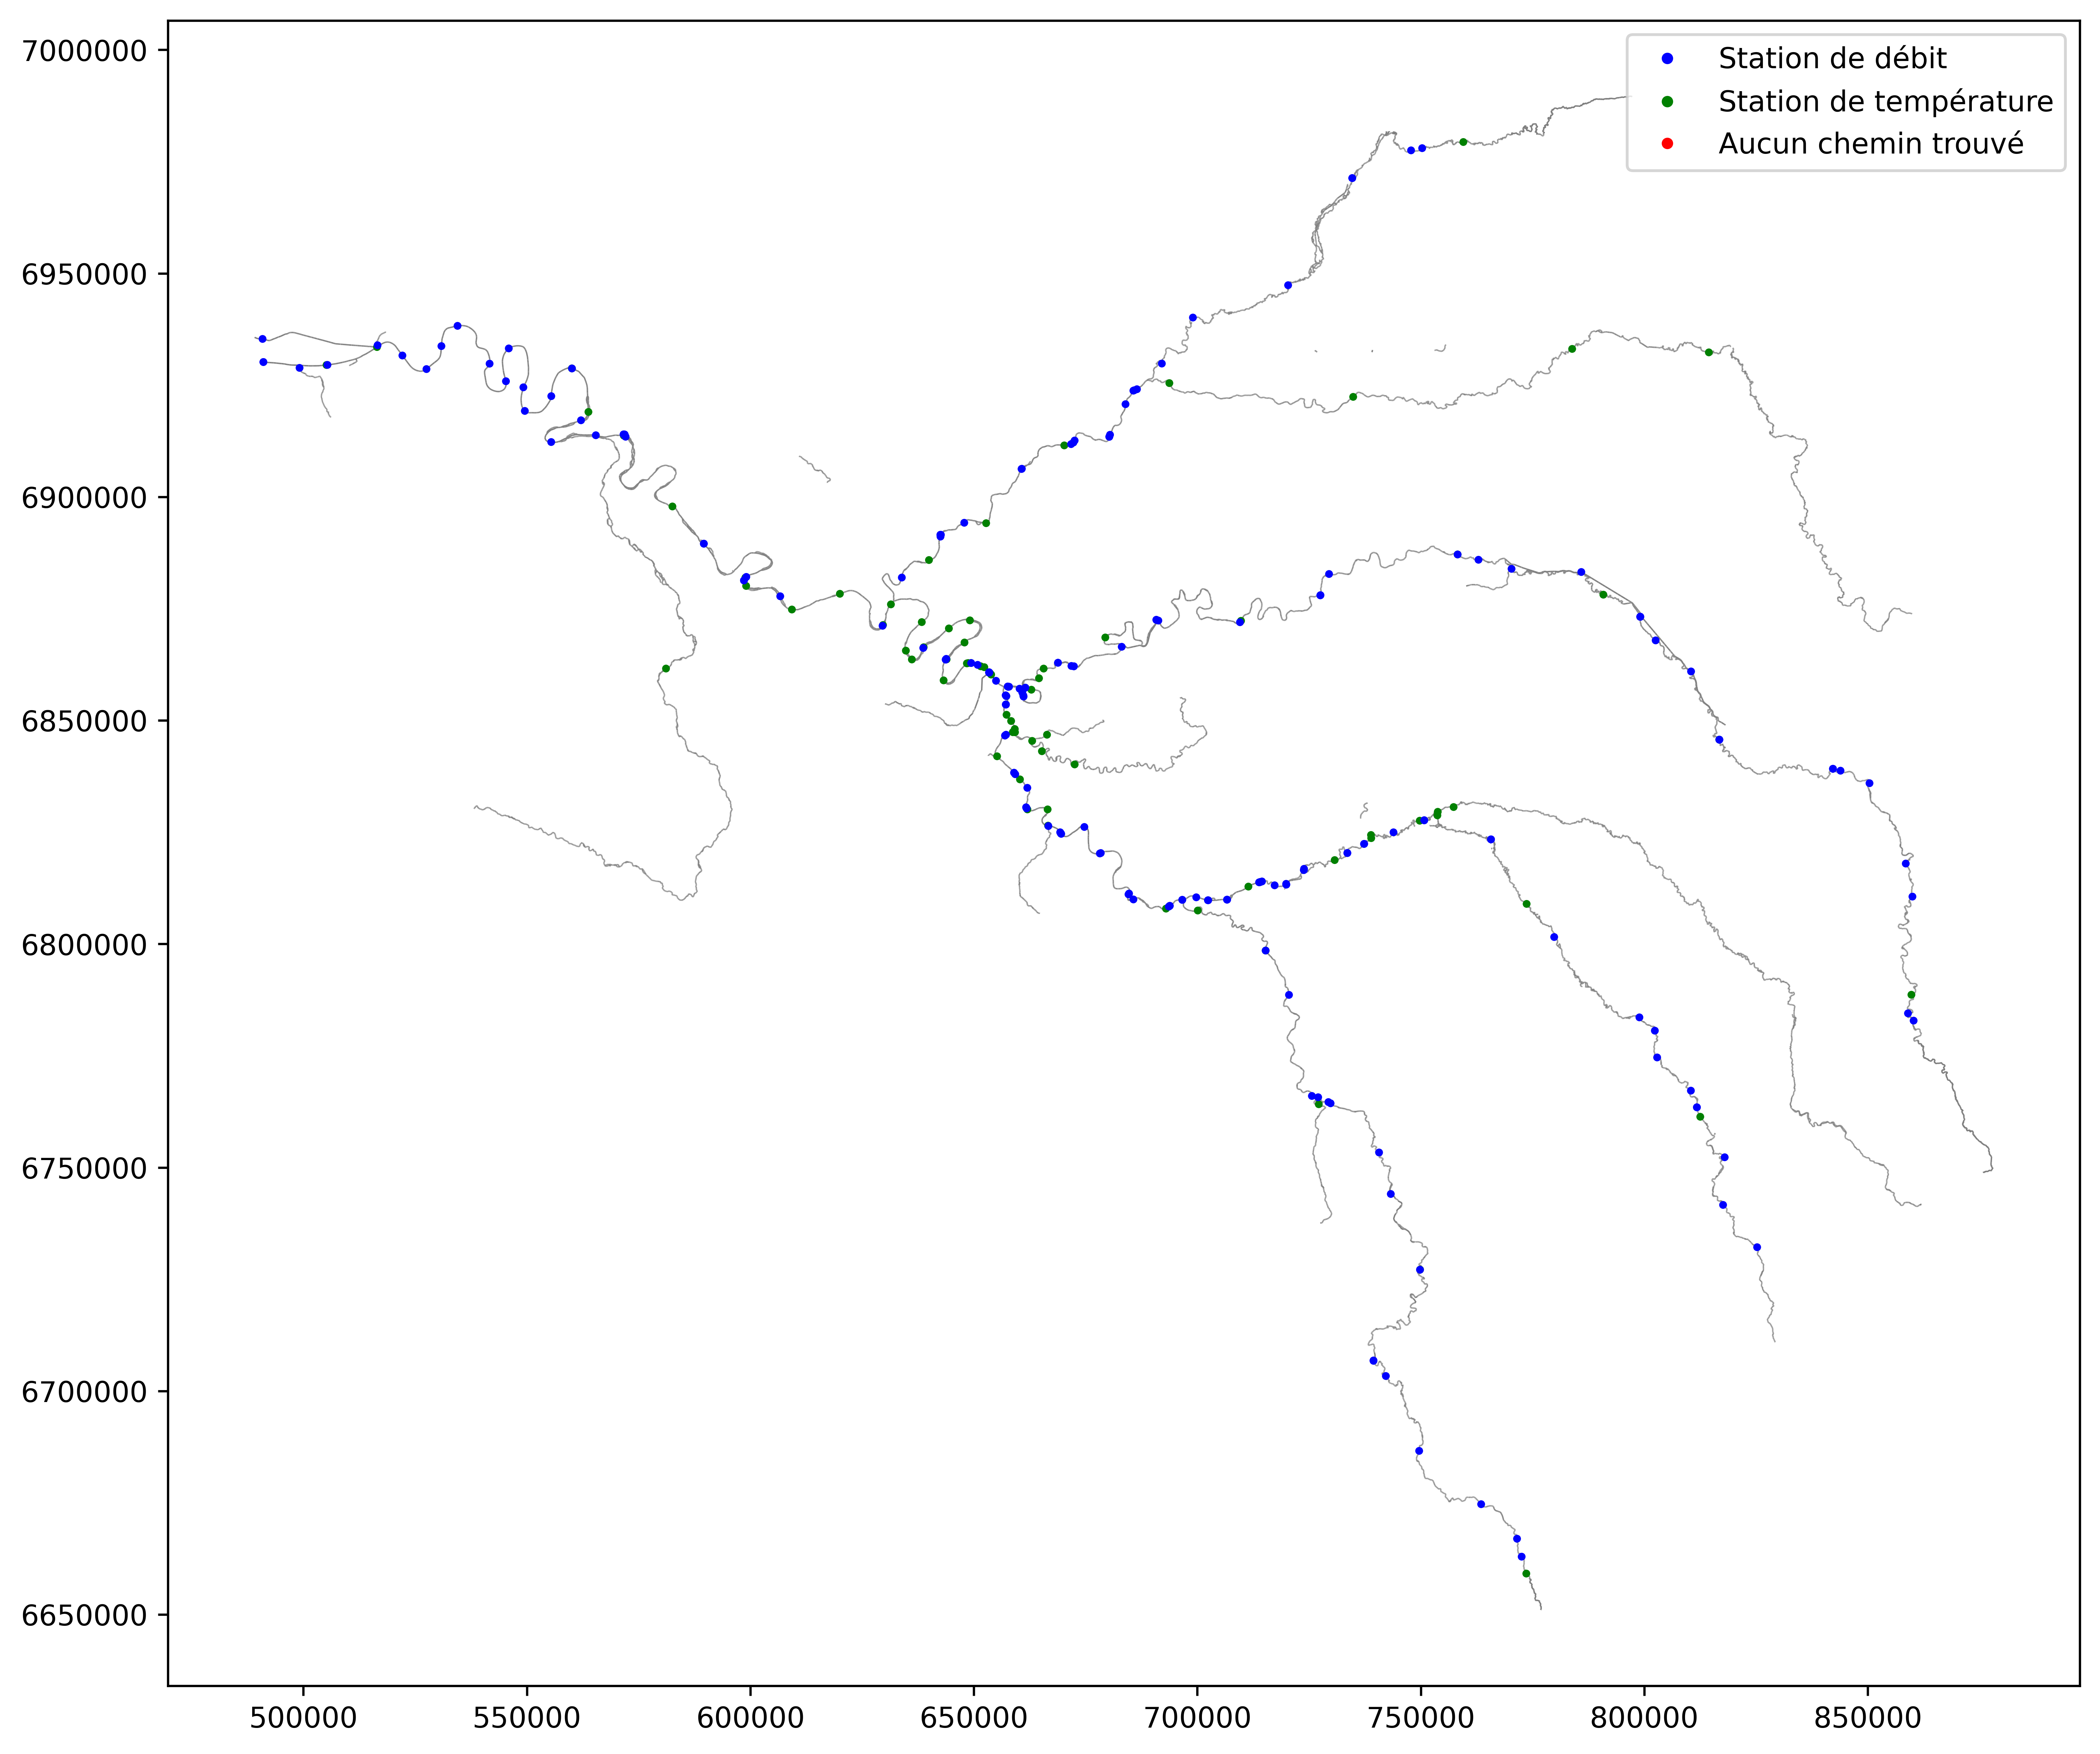

In [69]:
fig, ax = plt.subplots(figsize = (12,12), dpi = 600)
seine0.plot(ax = ax, lw = 0.5, color = "grey", zorder = -1)
points.plot(ax = ax, lw = 0.5,color = colors0, markersize = 5)
ax.ticklabel_format(style = 'plain', axis = 'both')
plt.legend(handles=[
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='blue', markersize=5, label='Station de débit'),
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='green', markersize=5, label='Station de température'),
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='red', markersize=5, label='Aucun chemin trouvé')
])
plt.show()

Sauvegarde du graphe dans un fichier annexe, pour ne pas avoir à recompiler :

In [70]:
pickle.dump(G2, open('Graphs/G_connexe_non_contracted.pickle', 'wb'))

**Sauvegarde et affichage de la version contractée :**

In [72]:
G2 = pickle.load(open('Graphs/G_connexe_non_contracted.pickle', 'rb'))

G2_contracted = contract(G2)

In [73]:
pickle.dump(G2_contracted, open('Graphs/G_connexe_contracted.pickle', 'wb'))

In [74]:
G_contract = pickle.load(open('Graphs/G_connexe_contracted.pickle', 'rb'))

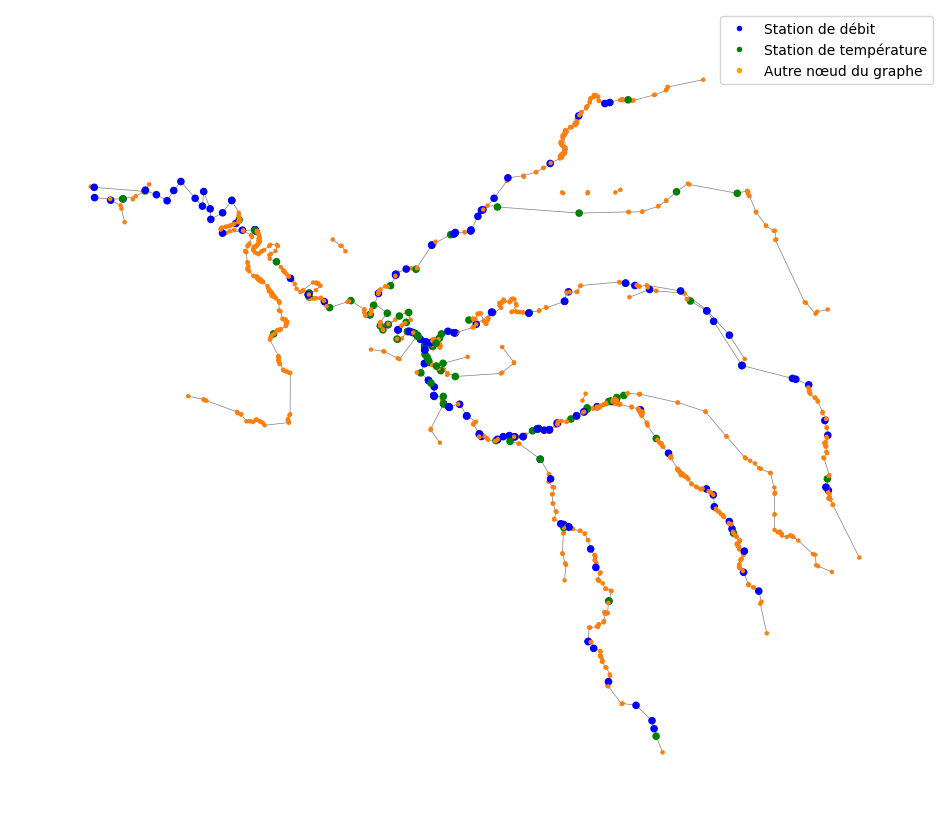

In [91]:
G_contract = pickle.load(open('Graphs/G_connexe_contracted.pickle', 'rb'))

pos_contract = {n: n for n in G_contract.nodes()}

node_colors = []
for n in G_contract.nodes():
    attrs = G_contract.nodes[n]
    if attrs.get("site_id") is None:
        node_colors.append("tab:orange")
    elif attrs.get("source") == "hubeau":
        node_colors.append("blue")
    else:
        node_colors.append("green")

node_sizes = [
    20 if G_contract.nodes[n].get("site_id") is not None else 5
    for n in G_contract.nodes()
]

fig, ax = plt.subplots(figsize=(12, 12))
nx.draw(
    G_contract,
    pos=pos_contract,
    ax=ax,
    node_color=node_colors,
    node_size=node_sizes,
    edge_color="tab:grey",
    width=0.5,
    with_labels=False,
)
ax.set_aspect("equal")

plt.legend(handles=[
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='blue', markersize=5, label='Station de débit'),
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='green', markersize=5, label='Station de température'),
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='orange', markersize=5, label='Autre nœud du graphe')
])
plt.show()

# IV. Orientation du graphe et prise en compte des distances

Programmation d'une fonction d'orientation du graphe hydrographique, à partir d'un graphe hydrographique CONNEXE non orienté, et de l'exutoire.

In [76]:
def dfs(graph, node):
    visited = set((node,))
    dg = nx.DiGraph()
    stack = [(node,0.)]
    dg.add_node(node)
    dg.nodes[node]["site_id"]=graph.nodes[node]["site_id"]
    dg.nodes[node]["dist_exut"] = 0.
    while stack:
        node,d = stack[-1]
        if node not in visited:
            visited.add(node)
        remove_from_stack = True
        for next_node,attrs in graph[node].items():
            if next_node not in visited:
                dg.add_edge(next_node,node,weight = attrs['weight'])
                dg.nodes[node]["site_id"] = graph.nodes[node].get("site_id")
                dg.nodes[next_node]["dist_exut"] = d + attrs['weight']
                stack.append((next_node,dg.nodes[node]["dist_exut"]))
                remove_from_stack = False
                break
        if remove_from_stack:
            stack.pop()
    return dg

In [77]:
G_oriented = dfs(G_contract, root_node)

In [78]:
pickle.dump(G_oriented, open('Graphs/G_oriented.pickle', 'wb'))

**visualisation du graphe orienté :**

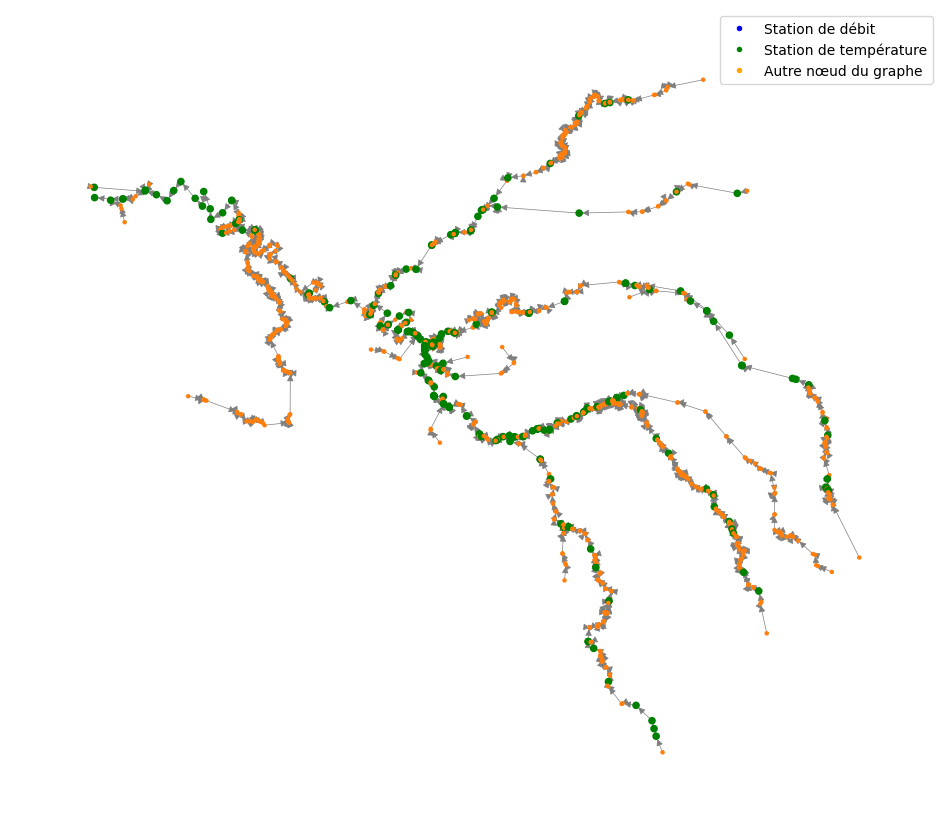

In [93]:
G_oriented = pickle.load(open('Graphs/G_oriented.pickle', 'rb'))   

pos_contract = {n: n for n in G_oriented.nodes()}

node_colors = []
for n in G_oriented.nodes():
    attrs = G_oriented.nodes[n]
    if attrs.get("site_id") is None:
        node_colors.append("tab:orange")
    elif attrs.get("source") == "hubeau":
        node_colors.append("blue")
    else:
        node_colors.append("green")

node_sizes = [
    20 if G_oriented.nodes[n].get("site_id") is not None else 5
    for n in G_oriented.nodes()
]

fig, ax = plt.subplots(figsize=(12, 12))
nx.draw(
    G_oriented,
    pos=pos_contract,
    ax=ax,
    node_color=node_colors,
    node_size=node_sizes,
    edge_color="tab:grey",
    width=0.5,
    with_labels=False,
)
ax.set_aspect("equal")

plt.legend(handles=[
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='blue', markersize=5, label='Station de débit'),
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='green', markersize=5, label='Station de température'),
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='orange', markersize=5, label='Autre nœud du graphe')
])

plt.show()

**Visualisation du graphe avec cmap qui varie selon la distance des stations (les points) à l'estuaire :**

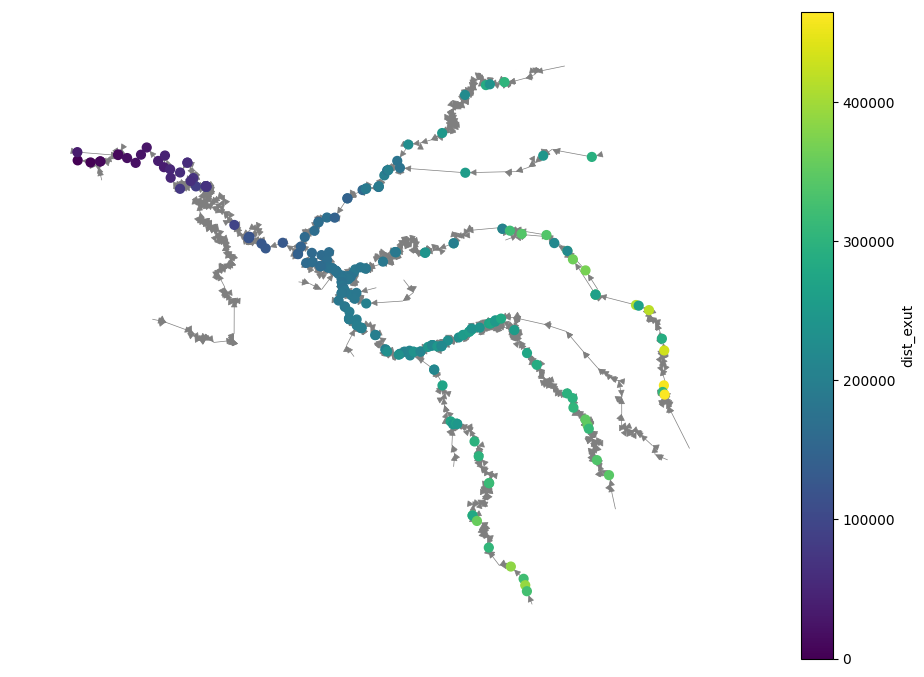

In [94]:
dist_exut_values = [G_oriented.nodes[n].get("dist_exut",0.) for n in G_oriented.nodes()]

pos_contract = {n: n for n in G_oriented.nodes()}
# Normalisation des valeurs pour la colormap
norm = mcolors.Normalize(vmin=min(dist_exut_values), vmax=max(dist_exut_values))
cmap = cm.viridis  # tu peux changer pour "plasma", "coolwarm", "turbo", etc.

node_colors = [cmap(norm(v)) for v in dist_exut_values]

# Taille toujours différenciée stations / autres
node_sizes = [
    40 if G_oriented.nodes[n].get("site_id") is not None else 0
    for n in G_oriented.nodes()
]

fig, ax = plt.subplots(figsize=(12, 12))
nx.draw(
    G_oriented,
    pos=pos_contract,
    ax=ax,
    node_color=node_colors,
    node_size=node_sizes,
    edge_color="tab:grey",
    width=0.5,
    with_labels=False,
)

# Ajout d'une colorbar pour interpréter les couleurs
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, shrink=0.7)
cbar.set_label("dist_exut")

ax.set_aspect("equal")
plt.show()

# VI. Réduction du graphe

But de la section : réduire les arêtes au strict minimum en gardant la pondération par les distances, ie on a juste un graphe avec des lignes droites entre les stations de relevé (débit et température).